# Bloque 3 — Simulación coste de oportunidad HPO a 30 años

H3: La calificación HPO permanente que impone el Préstec genera una brecha patrimonial acumulada a 30 años que supera el beneficio inicial del préstamo, trasladando al beneficiario el coste de mantener stock asequible que debería asumir el Estado.

**Fuentes de datos**

**Serie histórica de precios (Idescat, 2013–2024)**
- **Fuente**: Idescat / Departament de Territori — *Preu mitjà de venda
  d'habitatges de segona mà*, datos anuales por comarca y provincia.
- **URL**: https://www.idescat.cat/indicadors/?id=aec&n=15707
- **Formato**: CSV anual descargado individualmente (un fichero por año).
- **Columnas relevantes**: `row` (geografía), `col` (tipo de dato),
  `value` (precio en €/m²).
- **Nota técnica**: Los ficheros 2013–2023 usan separador `;` y decimal `,`.
  El fichero 2024 usa separador `,` y decimal `.`. Se gestiona explícitamente
  en la carga.

**IPC de Cataluña (Idescat, 2013–2024)**
- **Fuente**: Idescat — *Índice de Precios de Consumo (IPC). Por grupos de
  consumo*, variación interanual mensual para Cataluña.
- **URL**: https://www.idescat.cat/indicadors/?id=basics&n=10261
- **Columna utilizada**: Índice general (columna 1 del CSV).
- **Tratamiento**: Se calcula la media de los 12 meses de cada año para obtener
  una variación anual representativa, y posteriormente la media del período
  2013–2024 como supuesto conservador para la proyección futura.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import pmdarima as pm
from pmdarima import auto_arima

## Carga de serie histórica de precios 

In [66]:
data = Path(".")

provincias = ["Barcelona", "Girona", "Lleida", "Tarragona"]

regiones = [
    "Catalunya", "Metropolità", "Comarques Gironines", "Camp de Tarragona",
    "Terres de l'Ebre", "Ponent", "Comarques Centrals",
    "Alt Pirineu i Aran", "Penedès"
]

excluir = set(provincias + regiones)

records = []

for year in range(2013, 2025):
    filepath = data / f"{year}-idescat-aec-15707-1.csv"

    if year == 2024:
        df_raw = pd.read_csv(filepath, encoding="utf-8-sig")
    else:
        df_raw = pd.read_csv(filepath, sep=";", decimal=",", encoding="utf-8-sig")

    df_val = df_raw[df_raw["col"] == "Valor"][["row", "value"]].copy()
    df_val.columns = ["geo", "precio_m2"]
    df_val["año"] = year

    if year < 2024:
        df_val["precio_m2"] = (
            df_val["precio_m2"]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .pipe(pd.to_numeric, errors="coerce")
        )
    else:
        df_val["precio_m2"] = pd.to_numeric(df_val["precio_m2"], errors="coerce")

    records.append(df_val)

df_serie = pd.concat(records, ignore_index=True)

print("Shape df_serie:", df_serie.shape)
print("Años disponibles:", sorted(df_serie["año"].unique()))
print("Nulls en precio_m2:", df_serie["precio_m2"].isnull().sum())

Shape df_serie: (672, 3)
Años disponibles: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Nulls en precio_m2: 10


Separación de los niveles geográficos

In [67]:
df_serie_provincias = df_serie[df_serie["geo"].isin(provincias)].copy()
df_serie_comarcas = df_serie[~df_serie["geo"].isin(excluir)].copy()

print("Registros provincias:", len(df_serie_provincias))
print("Registros comarcas:", len(df_serie_comarcas))
print("Comarcas únicas:", df_serie_comarcas["geo"].nunique())


Registros provincias: 48
Registros comarcas: 516
Comarcas únicas: 43


### Nota metodológica: comarcas Lluçanès y Moianès

La comarca de Lluçanès no dispone de datos de precio hasta 2023. Idescat no publica valores para años anteriores, probablemente por volumen de transacciones insuficiente (comarca de nueva creación, 2015).
Por esta razón Lluçanès se **excluye del cálculo de CAGR y de la proyección a 30 años** por no disponer de una serie histórica representativa. No obstante, esta región sí aparece en los datos estáticos de 2024 del Bloque 2.

La comarca de Moianès registra precio 0 en 2013 (comarca de nueva creación, segregada de Bages en 2015; sin transacciones registradas en los primeros años del dataset). El cálculo de CAGR usa el primer año con precio válido y mayor que cero, ajustando el exponente al número real de años.

In [68]:
df_serie_comarcas = df_serie_comarcas[df_serie_comarcas["geo"] != "Lluçanès"].copy()

print("Comarcas tras excluir Lluçanès:", df_serie_comarcas["geo"].nunique())

Comarcas tras excluir Lluçanès: 42


## Carga del IPC

In [69]:
ipc = Path("IPC-idescat-basics-10261-1.csv")
df_ipc_raw = pd.read_csv(ipc, sep = ";", encoding = "utf-8-sig", header = None, skiprows = 7)

# El bloque de Cataluña ocupa las filas 0-299 (fila 0 es cabecera, datos desde fila 1)
df_ipc_raw = df_ipc_raw.iloc[:300].copy()

df_ipc = df_ipc_raw[[0, 1]].copy()
df_ipc.columns = ["fecha", "ipc_general"]

df_ipc["ipc_general"] = pd.to_numeric(
    df_ipc["ipc_general"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

# Solo filas con formato MM/AAAA
df_ipc = df_ipc[df_ipc["fecha"].astype(str).str.match(r"^\d{2}/\d{4}$")].copy()

df_ipc["año"] = df_ipc["fecha"].astype(str).str[-4:].astype(int)
df_ipc["mes"] = df_ipc["fecha"].astype(str).str[:2].astype(int)

df_ipc = df_ipc[(df_ipc["año"] >= 2013) & (df_ipc["año"] <= 2024)].copy()
df_ipc = df_ipc.sort_values(["año", "mes"]).reset_index(drop=True)

print("Filas:", len(df_ipc))
print("Duplicados:", df_ipc.duplicated(subset=["año", "mes"]).sum())
df_ipc.head(13)

# Media anual del IPC (media de los 12 meses de cada año)
ipc_anual = (
    df_ipc
    .groupby("año")["ipc_general"]
    .mean()
    .round(4)
    .reset_index()
    .rename(columns={"ipc_general": "ipc_medio_anual"})
)

# Supuesto conservador: media del período completo 2013-2024
ipc_medio_historico = round(ipc_anual["ipc_medio_anual"].mean(), 4)

print("IPC medio anual 2013-2024:")
print(ipc_anual.to_string(index=False))
print(f"\nSupuesto proyección HPO: {ipc_medio_historico}%")

Filas: 144
Duplicados: 0
IPC medio anual 2013-2024:
 año  ipc_medio_anual
2013           1.7417
2014           0.1250
2015          -0.1750
2016           0.0667
2017           2.1917
2018           1.8500
2019           0.8583
2020          -0.4250
2021           2.9167
2022           8.0083
2023           3.4083
2024           2.8417

Supuesto proyección HPO: 1.9507%


## Análisis de predicción

### Nota metodológica: predicción IPC

El IPC medio anual del Índice General de Cataluña para el período 2013–2024 es del **1.91%**. Este valor incluye años de deflación moderada (2014–2016) y el pico de 2022 (8.20%).

Se usa como supuesto conservador para la curva HPO porque:
1. Es la media histórica real del mismo período analizado para los precios
2. Infravalora el escenario más probable (la inflación reciente 2021–2024 supera la media).
3. Cualquier escenario de mayor inflación **amplía** la brecha patrimonial, no la reduce, lo que refuerza la hipótesis H3.

**Fuente**: Idescat, IPC de Cataluña, Índice general, variación interanual mensual 2013–2024.

### CAGR (Compound Annual Growth Rate)

Para calcular la tasa de revalorización de un inmueble, se usa una métrica financiera que calcula el rendimiento anual promedio de una inversión o negocio durante un período de tiempo superior a un año. Para ello se calcula como CAGR entre el primer año con dato
disponible y el 2024, último año disponible:

    CAGR = (precio_final / precio_inicial)^(1 / n_años) - 1

Donde `n_años` es el número de años entre el primer dato y 2024.

**Utilidad de esta métrica**
La CAGR es la tasa que, aplicada de forma compuesta, reproduce exactamente el recorrido histórico observado entre los dos extremos. La media aritmética sobreestima sistemáticamente el crecimiento real cuando hay volatilidad interanual. La proyección a 30 años aplica la tasa de forma compuesta (precio × (1+r)^t).

A nivel provincial se usa el período completo 2013–2024 (11 años) para todas las provincias. A nivel comarcal, si el primer dato disponible es posterior a 2013, el exponente se ajusta al número real de años observados.

In [70]:
def calcular_cagr(precio_inicial, precio_final, n_años):
    """Calcula la CAGR entre dos precios dados el número de años."""
    if precio_inicial is None or precio_final is None:
        return np.nan
    if precio_inicial <= 0 or n_años <= 0:
        return np.nan
    return (precio_final / precio_inicial) ** (1 / n_años) - 1

CARG Provincial

In [71]:
pivot_provincias = df_serie_provincias.pivot(
    index = "geo", columns = "año", values = "precio_m2"
)

cagr_provincias = []

for provincia in provincias:
    precio_2013 = pivot_provincias.loc[provincia, 2013]
    precio_2024 = pivot_provincias.loc[provincia, 2024]
    cagr = calcular_cagr(precio_2013, precio_2024, n_años=11)
    cagr_provincias.append({
        "provincia": provincia,
        "precio_2013": round(precio_2013, 2),
        "precio_2024": round(precio_2024, 2),
        "numero_años": 11,
        "cagr": round(cagr * 100, 4)  # en porcentaje
    })

df_cagr_provincias = pd.DataFrame(cagr_provincias)


print("CAGR por provincia (2013 y 2024):")
print(df_cagr_provincias.to_string(index = False))


CAGR por provincia (2013 y 2024):
provincia  precio_2013  precio_2024  numero_años   cagr
Barcelona      1920.78      2882.05           11 3.7577
   Girona      1820.82      2284.48           11 2.0837
   Lleida       963.05      1292.68           11 2.7122
Tarragona      1256.23      1634.83           11 2.4237


CAGR comarcal

In [72]:
mapa_provincial = {
    "Alt Camp": "Tarragona", "Baix Camp": "Tarragona", "Baix Penedès": "Tarragona",
    "Conca de Barberà": "Tarragona", "Priorat": "Tarragona", "Tarragonès": "Tarragona",
    "Ribera d'Ebre": "Tarragona", "Terra Alta": "Tarragona",
    "Alt Empordà": "Girona", "Baix Empordà": "Girona", "Cerdanya": "Girona",
    "Garrotxa": "Girona", "Gironès": "Girona", "Pla de l'Estany": "Girona",
    "Ripollès": "Girona", "Selva": "Girona",
    "Alt Urgell": "Lleida", "Alta Ribagorça": "Lleida", "Aran": "Lleida",
    "Garrigues": "Lleida", "Noguera": "Lleida", "Pallars Jussà": "Lleida",
    "Pallars Sobirà": "Lleida", "Pla d'Urgell": "Lleida", "Segarra": "Lleida",
    "Segrià": "Lleida", "Solsonès": "Lleida", "Urgell": "Lleida",
    "Alt Penedès": "Barcelona", "Anoia": "Barcelona", "Bages": "Barcelona",
    "Baix Ebre": "Tarragona", "Montsià": "Tarragona",
    "Baix Llobregat": "Barcelona", "Barcelonès": "Barcelona",
    "Berguedà": "Barcelona", "Garraf": "Barcelona",
    "Maresme": "Barcelona", "Moianès": "Barcelona", "Osona": "Barcelona",
    "Ripollès": "Girona", "Vallès Occidental": "Barcelona",
    "Vallès Oriental": "Barcelona",
}

pivot_comarcas = df_serie_comarcas.pivot(
    index="geo", columns="año", values="precio_m2"
)

cagr_comarcas = []

for comarca in pivot_comarcas.index:
    fila = pivot_comarcas.loc[comarca]
    datos_validos = fila.dropna()
    datos_validos = datos_validos[datos_validos > 0]

    if len(datos_validos) < 2:
        continue

    primer_año = datos_validos.index.min()
    precio_inicial = datos_validos[primer_año]
    precio_2024 = datos_validos.get(2024, np.nan)

    if pd.isna(precio_2024):
        continue

    n_años = 2024 - primer_año
    cagr = calcular_cagr(precio_inicial, precio_2024, n_años)

    cagr_comarcas.append({
        "comarca": comarca,
        "provincia": mapa_provincial.get(comarca, "Desconocida"),
        "primer_año": primer_año,
        "precio_primer_año": round(precio_inicial, 2),
        "precio_2024": round(precio_2024, 2),
        "n_años": n_años,
        "cagr": round(cagr * 100, 4)
    })

df_cagr_comarcas = pd.DataFrame(cagr_comarcas)

print("CAGR por comarca:")
print(df_cagr_comarcas.sort_values("cagr", ascending=False).to_string(index=False))

CAGR por comarca:
          comarca provincia  primer_año  precio_primer_año  precio_2024  n_años    cagr
       Terra Alta Tarragona        2013             755.96      1347.47      11  5.3950
            Osona Barcelona        2013             881.67      1547.31      11  5.2462
             Aran    Lleida        2013            1875.31      3158.56      11  4.8536
          Gironès    Girona        2013            1196.37      1971.42      11  4.6452
Vallès Occidental Barcelona        2013            1451.19      2372.22      11  4.5690
   Alta Ribagorça    Lleida        2013             938.71      1518.97      11  4.4724
          Maresme Barcelona        2013            1582.76      2538.60      11  4.3885
       Barcelonès Barcelona        2013            2404.26      3827.76      11  4.3183
       Alt Urgell    Lleida        2013             942.73      1431.44      11  3.8699
  Vallès Oriental Barcelona        2013            1383.35      2088.52      11  3.8160
         Cerda

### Proyección a 30 años

In [73]:
años_proyeccion = 30
m2_ejemplo = 60  # m2 de vivienda para ilustrar en euros totales


def proyectar_curvas(precio_base_m2, tasa_mercado_pct, tasa_ipc_pct, n_años=30):
    """
    Proyecta dos curvas a n años desde un precio base.
    Parámetros
    precio_base_m2   : precio inicial en €/m²
    tasa_mercado_pct : CAGR histórica en % (ej. 3.5 para 3.5%)
    tasa_ipc_pct     : IPC medio histórico en % (ej. 1.91 para 1.91%)
    n_años          : horizonte de proyección
    Retorna
    DataFrame con columnas: año, precio_mercado_m2, precio_hpo_m2, brecha_m2
    """
    tasa_m = tasa_mercado_pct / 100
    tasa_i = tasa_ipc_pct / 100

    años = list(range(0, n_años + 1))
    mercado = [precio_base_m2 * (1 + tasa_m) ** t for t in años]
    hpo = [precio_base_m2 * (1 + tasa_i) ** t for t in años]
    brecha = [m - h for m, h in zip(mercado, hpo)]

    return pd.DataFrame({
        "año_proyeccion": años,
        "precio_mercado_m2": [round(v, 2) for v in mercado],
        "precio_hpo_m2": [round(v, 2) for v in hpo],
        "brecha_m2": [round(v, 2) for v in brecha]
    })


Proyeccion provincial

In [74]:
proyecciones_provincias = {}

for _, fila in df_cagr_provincias.iterrows():
    df_proj = proyectar_curvas(
        precio_base_m2=fila["precio_2024"],
        tasa_mercado_pct=fila["cagr"],
        tasa_ipc_pct=ipc_medio_historico,
        n_años=años_proyeccion
    )
    df_proj["provincia"] = fila["provincia"]
    proyecciones_provincias[fila["provincia"]] = df_proj

df_proyecciones_provincias = pd.concat(
    proyecciones_provincias.values(), ignore_index=True
)

# Resumen al año 30
df_resumen_provincias = (
    df_proyecciones_provincias[df_proyecciones_provincias["año_proyeccion"] == 30]
    [[
        "provincia", "precio_mercado_m2", "precio_hpo_m2", "brecha_m2"
    ]]
    .copy()
)

df_resumen_provincias["brecha_60m2"] = (
    df_resumen_provincias["brecha_m2"] * m2_ejemplo
).round(0).astype(int)

print("Brecha patrimonial al año 30 por provincia:")
print(df_resumen_provincias.to_string(index=False))

Brecha patrimonial al año 30 por provincia:
provincia  precio_mercado_m2  precio_hpo_m2  brecha_m2  brecha_60m2
Barcelona            8715.89        5145.27    3570.62       214237
   Girona            4241.11        4078.44     162.67         9760
   Lleida            2885.04        2307.80     577.25        34635
Tarragona            3353.41        2918.63     434.78        26087


Proyeccion comarcal

In [85]:
proyecciones_comarcas = []

for _, fila in df_cagr_comarcas.iterrows():
    df_proj = proyectar_curvas(
        precio_base_m2=fila["precio_2024"],
        tasa_mercado_pct=fila["cagr"],
        tasa_ipc_pct=ipc_medio_historico,
        n_años=años_proyeccion
    )
    df_proj["comarca"] = fila["comarca"]
    df_proj["provincia"] = fila["provincia"]
    proyecciones_comarcas.append(df_proj)

df_proyecciones_comarcas = pd.concat(proyecciones_comarcas, ignore_index=True)

df_resumen_comarcas = (
    df_proyecciones_comarcas[df_proyecciones_comarcas["año_proyeccion"] == 30]
    [[
        "comarca", "provincia", "precio_mercado_m2", "precio_hpo_m2", "brecha_m2"
    ]]
    .copy()
)

df_resumen_comarcas["brecha_60m2"] = (
    df_resumen_comarcas["brecha_m2"] * m2_ejemplo
).round(0).astype(int)

print("Top 10 comarcas por brecha patrimonial al año 30:")
print(
    df_resumen_comarcas
    .sort_values("brecha_m2", ascending=False)
    .head(10)
    .to_string(index=False))

Top 10 comarcas por brecha patrimonial al año 30:
          comarca provincia  precio_mercado_m2  precio_hpo_m2  brecha_m2  brecha_60m2
             Aran    Lleida           13091.50        5638.91    7452.59       447155
       Barcelonès Barcelona           13606.92        6833.62    6773.29       406397
Vallès Occidental Barcelona            9062.41        4235.08    4827.33       289640
          Maresme Barcelona            9208.18        4532.11    4676.07       280564
            Osona Barcelona            7174.14        2762.38    4411.76       264706
          Gironès    Girona            7697.66        3519.54    4178.12       250687
       Terra Alta Tarragona            6518.07        2405.61    4112.46       246748
         Cerdanya    Girona            9197.66        5388.55    3809.12       228547
     Baix Empordà    Girona            8239.64        4827.56    3412.08       204725
   Baix Llobregat Barcelona            8148.58        5042.40    3106.18       186371


## Visualizaciones del Bloque 3

Se generan cuatro visualizaciones:

1. **Curvas dobles provinciales** — evolución a 30 años de precio mercado vs precio HPO para las 4 provincias catalanas. Permite ver cuándo se abre la brecha y con qué pendiente.

2. **Barras de brecha al año 30 (provincial)** — magnitud en €/m² y en € para una vivienda de 60 m², ordenadas de mayor a menor.

3. **Heatmap comarcal de brecha al año 30** — muestra la distribución territorial de la pérdida patrimonial dentro de cada provincia.

4. **Análisis de sensibilidad** — brecha al año 30 para Barcelona bajo tres escenarios de revalorización (CAGR histórica, CAGR +1pp, CAGR −1pp), manteniendo el IPC constante.

Gráfica 1 — Curvas dobles por provincia

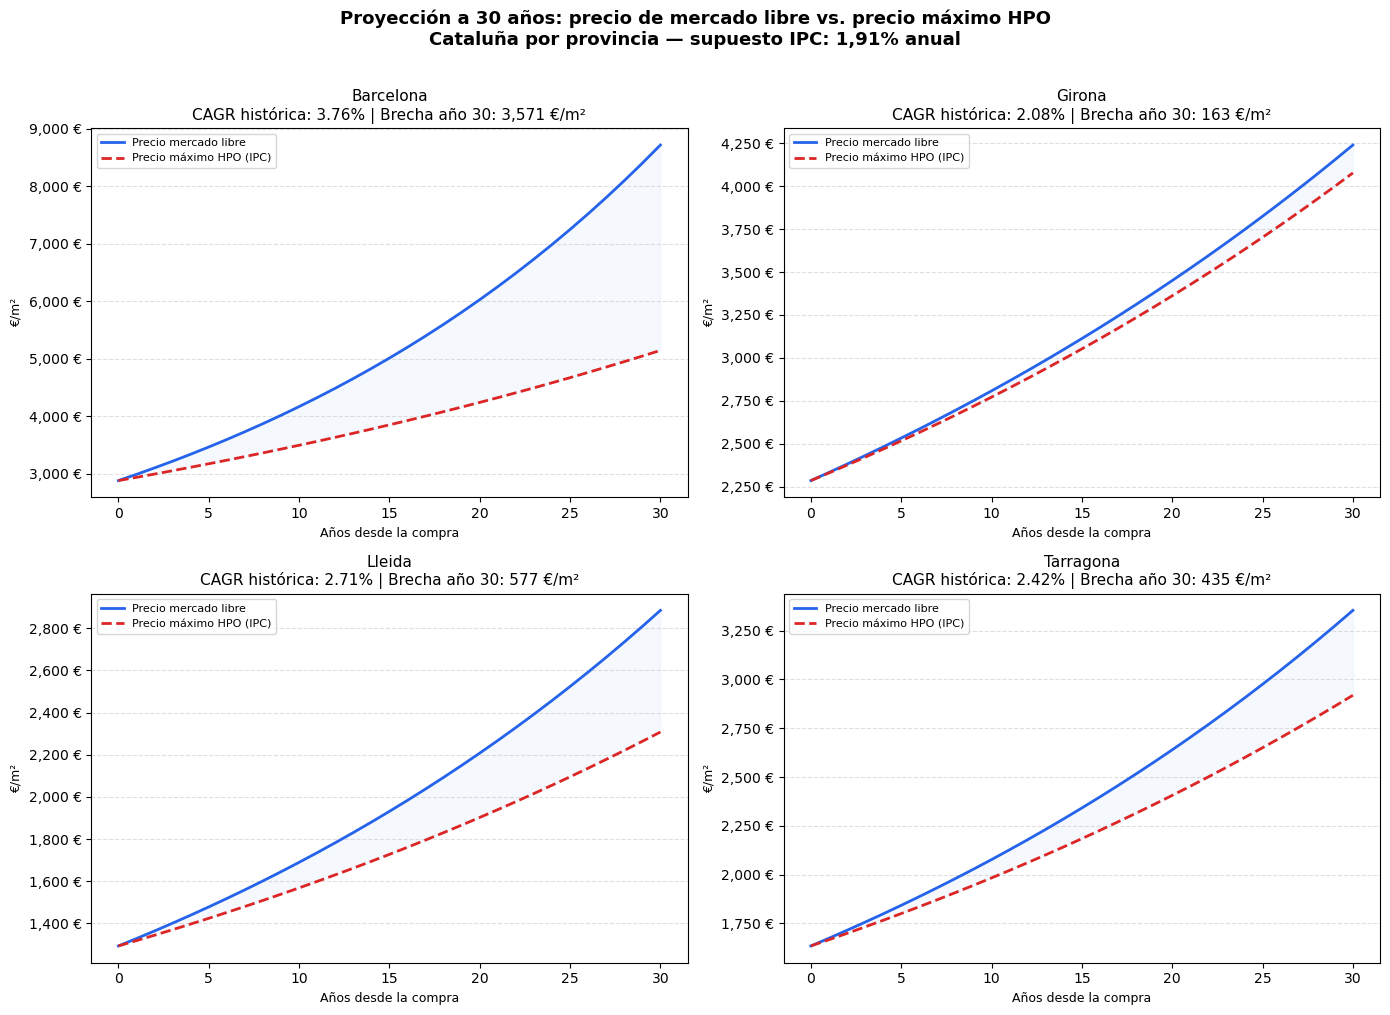

Guardada: bloque3_viz1_curvas_provinciales.png


In [88]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colores = {
    "mercado": "#2563EB",
    "hpo": "#DC2626",
    "relleno": "#BFDBFE"
}

for i, provincia in enumerate(provincias):
    ax = axes[i]
    df_p = proyecciones_provincias[provincia]

    ax.fill_between(
        df_p["año_proyeccion"],
        df_p["precio_hpo_m2"],
        df_p["precio_mercado_m2"],
        alpha=0.15,
        color=colores["relleno"],
        label="_nolegend_"
    )

    ax.plot(
        df_p["año_proyeccion"],
        df_p["precio_mercado_m2"],
        color=colores["mercado"],
        linewidth=2,
        label="Precio mercado libre"
    )
    ax.plot(
        df_p["año_proyeccion"],
        df_p["precio_hpo_m2"],
        color=colores["hpo"],
        linewidth=2,
        linestyle="--",
        label="Precio máximo HPO (IPC)"
    )

    brecha_final = df_p[df_p["año_proyeccion"] == 30]["brecha_m2"].values[0]
    cagr_val = df_cagr_provincias[
        df_cagr_provincias["provincia"] == provincia
    ]["cagr"].values[0]

    ax.set_title(
        f"{provincia}\nCAGR histórica: {cagr_val:.2f}% | "
        f"Brecha año 30: {brecha_final:,.0f} €/m²",
        fontsize=11
    )
    ax.set_xlabel("Años desde la compra", fontsize=9)
    ax.set_ylabel("€/m²", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x:,.0f} €"
    ))
    ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle(
    "Proyección a 30 años: precio de mercado libre vs. precio máximo HPO\n"
    "Cataluña por provincia — supuesto IPC: 1,91% anual",
    fontsize=13,
    fontweight="bold",
    y=1.01
)
plt.tight_layout()
plt.savefig("bloque3_viz1_curvas_provinciales.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada: bloque3_viz1_curvas_provinciales.png")


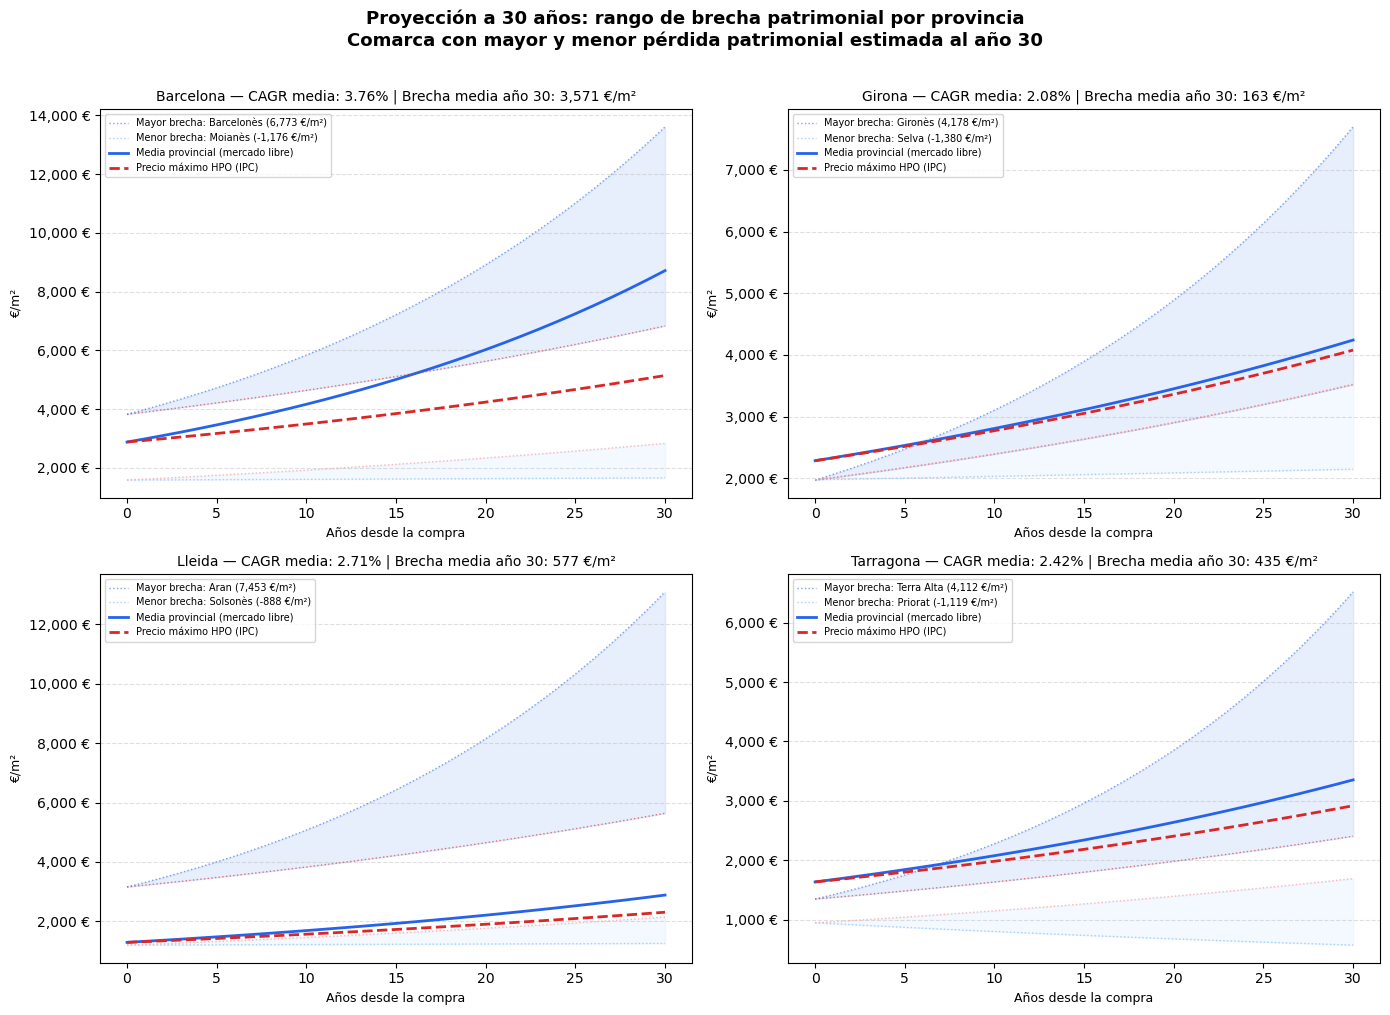

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, provincia in enumerate(provincias):
    ax = axes[i]

    comarcas_prov = df_resumen_comarcas_full[
        df_resumen_comarcas_full["provincia"] == provincia
    ]
    fila_max = comarcas_prov.loc[comarcas_prov["brecha_m2"].idxmax()]
    fila_min = comarcas_prov.loc[comarcas_prov["brecha_m2"].idxmin()]

    df_media = proyecciones_provincias[provincia]
    df_max = proyectar_curvas(fila_max["precio_2024"], fila_max["cagr"],
                              ipc_medio_historico, n_años=años_proyeccion)
    df_min = proyectar_curvas(fila_min["precio_2024"], fila_min["cagr"],
                              ipc_medio_historico, n_años=años_proyeccion)

    # Curvas mercado
    ax.plot(df_max["año_proyeccion"], df_max["precio_mercado_m2"],
            color="#2563EB", linewidth=1, linestyle=":", alpha=0.6,
            label=f"Mayor brecha: {fila_max['comarca']} ({fila_max['brecha_m2']:,.0f} €/m²)")
    ax.plot(df_min["año_proyeccion"], df_min["precio_mercado_m2"],
            color="#93C5FD", linewidth=1, linestyle=":", alpha=0.8,
            label=f"Menor brecha: {fila_min['comarca']} ({fila_min['brecha_m2']:,.0f} €/m²)")
    ax.plot(df_media["año_proyeccion"], df_media["precio_mercado_m2"],
            color="#2563EB", linewidth=2,
            label="Media provincial (mercado libre)")

    # Curvas HPO
    ax.plot(df_max["año_proyeccion"], df_max["precio_hpo_m2"],
            color="#DC2626", linewidth=1, linestyle=":", alpha=0.6)
    ax.plot(df_min["año_proyeccion"], df_min["precio_hpo_m2"],
            color="#FCA5A5", linewidth=1, linestyle=":", alpha=0.8)
    ax.plot(df_media["año_proyeccion"], df_media["precio_hpo_m2"],
            color="#DC2626", linewidth=2, linestyle="--",
            label="Precio máximo HPO (IPC)")

    # Bandas de brecha
    ax.fill_between(df_max["año_proyeccion"],
                    df_max["precio_hpo_m2"], df_max["precio_mercado_m2"],
                    alpha=0.10, color="#2563EB")
    ax.fill_between(df_min["año_proyeccion"],
                    df_min["precio_hpo_m2"], df_min["precio_mercado_m2"],
                    alpha=0.10, color="#93C5FD")

    cagr_val = df_cagr_provincias[
        df_cagr_provincias["provincia"] == provincia]["cagr"].values[0]
    brecha_media = df_media[df_media["año_proyeccion"] == 30]["brecha_m2"].values[0]

    ax.set_title(
        f"{provincia} — CAGR media: {cagr_val:.2f}% | "
        f"Brecha media año 30: {brecha_media:,.0f} €/m²",
        fontsize=10
    )
    ax.set_xlabel("Años desde la compra", fontsize=9)
    ax.set_ylabel("€/m²", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €"))
    ax.legend(fontsize=7)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle(
    "Proyección a 30 años: rango de brecha patrimonial por provincia\n"
    "Comarca con mayor y menor pérdida patrimonial estimada al año 30",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("bloque3_viz_dispersion_comarcal.png", dpi=150, bbox_inches="tight")
plt.show()

Gráfica 2 — Barras de brecha al año 30 (provincial)

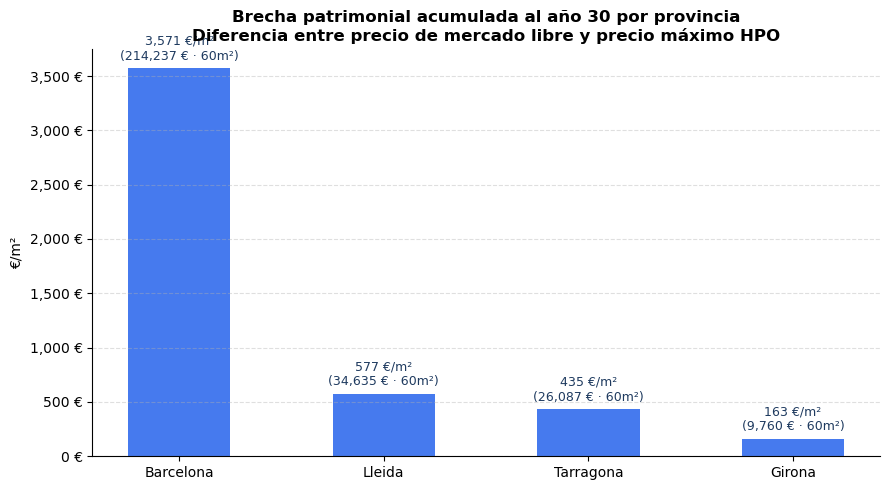

Guardada: bloque3_viz2_barras_brecha_provincial.png


In [89]:
df_barras = df_resumen_provincias.sort_values("brecha_m2", ascending=False).copy()

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    df_barras["provincia"],
    df_barras["brecha_m2"],
    color="#2563EB",
    alpha=0.85,
    width=0.5
)

for bar, (_, fila) in zip(bars, df_barras.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{fila['brecha_m2']:,.0f} €/m²\n({fila['brecha_60m2']:,} € · 60m²)",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#1E3A5F"
    )

ax.set_title(
    "Brecha patrimonial acumulada al año 30 por provincia\n"
    "Diferencia entre precio de mercado libre y precio máximo HPO",
    fontsize=12,
    fontweight="bold"
)
ax.set_ylabel("€/m²", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €"))
ax.set_xlabel("")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("bloque3_viz2_barras_brecha_provincial.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada: bloque3_viz2_barras_brecha_provincial.png")

Gráfica 3 - Heatmap comarcal de brecha al año 30

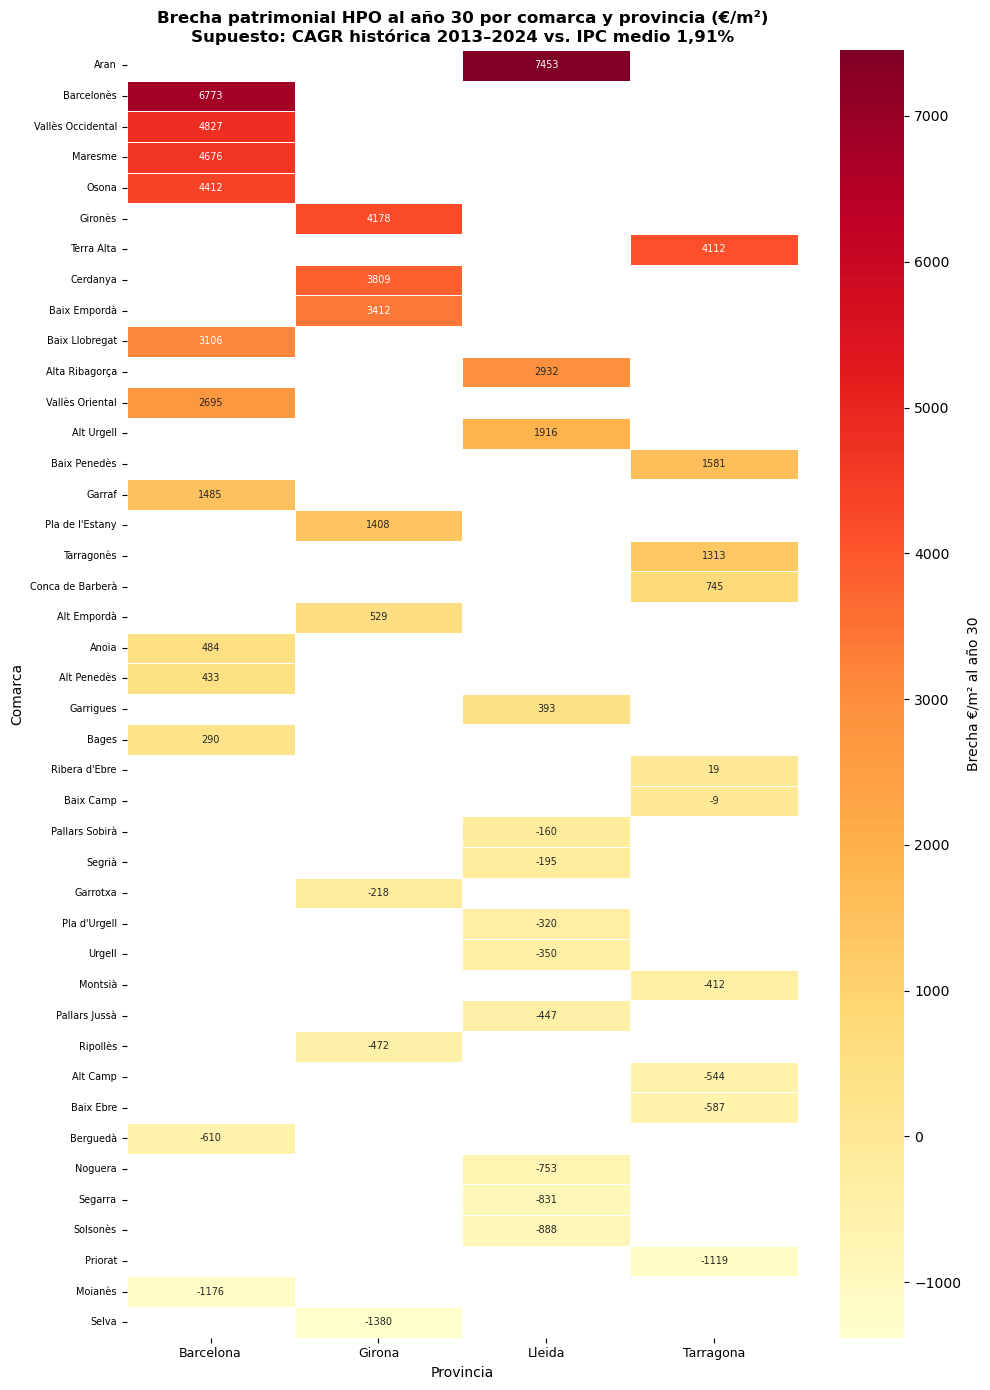

Guardada: bloque3_viz3_heatmap_comarcas.png


In [90]:
pivot_heatmap = df_resumen_comarcas.pivot_table(
    index="comarca",
    columns="provincia",
    values="brecha_m2"
)

# Ordenar comarcas por brecha máxima
pivot_heatmap = pivot_heatmap.loc[
    pivot_heatmap.max(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(10, 14))

sns.heatmap(
    pivot_heatmap,
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.4,
    cbar_kws={"label": "Brecha €/m² al año 30"},
    annot_kws={"size": 7}
)

ax.set_title(
    "Brecha patrimonial HPO al año 30 por comarca y provincia (€/m²)\n"
    "Supuesto: CAGR histórica 2013–2024 vs. IPC medio 1,91%",
    fontsize=12,
    fontweight="bold"
)
ax.set_xlabel("Provincia", fontsize=10)
ax.set_ylabel("Comarca", fontsize=10)
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("bloque3_viz3_heatmap_comarcas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada: bloque3_viz3_heatmap_comarcas.png")

Gráfica 4 — Análisis de sensibilidad (Barcelona)
Se proyectan tres escenarios para la provincia de Barcelona, manteniendo el IPC constante (1,91%):

- **Escenario base**: CAGR histórica 2013–2024
- **Escenario alto**: CAGR + 1 punto porcentual
- **Escenario bajo**: CAGR − 1 punto porcentual

El objetivo es mostrar que incluso en el escenario más conservador (CAGR histórica − 1pp), la brecha patrimonial al año 30 es sustancial.


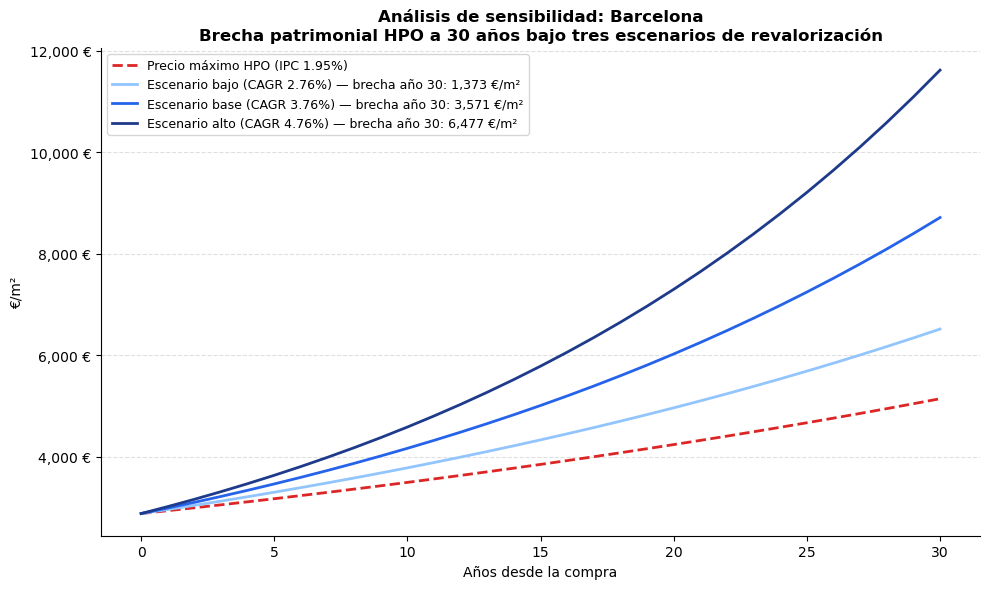

Guardada: bloque3_viz4_sensibilidad_barcelona.png


In [91]:
cagr_bcn = df_cagr_provincias[
    df_cagr_provincias["provincia"] == "Barcelona"
]["cagr"].values[0]

precio_base_bcn = df_cagr_provincias[
    df_cagr_provincias["provincia"] == "Barcelona"
]["precio_2024"].values[0]

escenarios = {
    f"Escenario bajo (CAGR {cagr_bcn - 1:.2f}%)": cagr_bcn - 1,
    f"Escenario base (CAGR {cagr_bcn:.2f}%)": cagr_bcn,
    f"Escenario alto (CAGR {cagr_bcn + 1:.2f}%)": cagr_bcn + 1,
}

colores_escenarios = ["#93C5FD", "#2563EB", "#1E3A8A"]

fig, ax = plt.subplots(figsize=(10, 6))

df_hpo_ref = proyectar_curvas(precio_base_bcn, cagr_bcn, ipc_medio_historico)
ax.plot(
    df_hpo_ref["año_proyeccion"],
    df_hpo_ref["precio_hpo_m2"],
    color="#DC2626",
    linewidth=2,
    linestyle="--",
    label=f"Precio máximo HPO (IPC {ipc_medio_historico:.2f}%)"
)

for (etiqueta, tasa), color in zip(escenarios.items(), colores_escenarios):
    df_esc = proyectar_curvas(precio_base_bcn, tasa, ipc_medio_historico)
    brecha_30 = df_esc[df_esc["año_proyeccion"] == 30]["brecha_m2"].values[0]
    ax.plot(
        df_esc["año_proyeccion"],
        df_esc["precio_mercado_m2"],
        color=color,
        linewidth=2,
        label=f"{etiqueta} — brecha año 30: {brecha_30:,.0f} €/m²"
    )

ax.set_title(
    "Análisis de sensibilidad: Barcelona\n"
    "Brecha patrimonial HPO a 30 años bajo tres escenarios de revalorización",
    fontsize=12,
    fontweight="bold"
)
ax.set_xlabel("Años desde la compra", fontsize=10)
ax.set_ylabel("€/m²", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €"))
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("bloque3_viz4_sensibilidad_barcelona.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada: bloque3_viz4_sensibilidad_barcelona.png")

In [100]:
# Unir brecha con precio_2024 y cagr
df_resumen_comarcas_full = df_resumen_comarcas.merge(
    df_cagr_comarcas[["comarca", "precio_2024", "cagr"]],
    on="comarca",
    how="left"
)

print(df_resumen_comarcas_full.columns.tolist())
print(df_resumen_comarcas_full.head(2))

['comarca', 'provincia', 'precio_mercado_m2', 'precio_hpo_m2', 'brecha_m2', 'brecha_60m2', 'precio_2024', 'cagr']
       comarca  provincia  precio_mercado_m2  precio_hpo_m2  brecha_m2  \
0     Alt Camp  Tarragona            1444.47        1988.52    -544.04   
1  Alt Empordà     Girona            4897.43        4368.04     529.39   

   brecha_60m2  precio_2024    cagr  
0       -32642      1113.84  0.8702  
1        31763      2446.70  2.3402  


Las comarcas con brecha negativa (Moianès, Priorat, Solsonès, Selva) no indican una ventaja del HPO, sino que en esos mercados la revalorización histórica ha sido inferior al IPC. En estos casos la restricción HPO no genera pérdida patrimonial medible con los datos disponibles, pero tampoco genera ganancia — el beneficiario simplemente no captura revalorización en ninguno de los dos escenarios.

### Predicción ARIMA

In [77]:
# Crear serie temporal ordenada
serie_ipc = df_ipc["ipc_general"].values

# auto_arima selecciona automáticamente los mejores parámetros p, d, q
modelo_arima = auto_arima(
    serie_ipc,
    seasonal=True,
    m=12,              # estacionalidad mensual
    stepwise=True,     # búsqueda eficiente
    information_criterion="aic",
    trace=True,        # muestra los modelos que prueba
    error_action="ignore",
    suppress_warnings=True
)

print(modelo_arima.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=228.255, Time=0.88 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=276.567, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=250.536, Time=0.09 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=225.601, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=274.570, Time=0.00 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=274.966, Time=0.06 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=227.506, Time=0.20 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=227.475, Time=0.37 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=250.656, Time=0.10 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=inf, Time=1.25 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=230.022, Time=0.38 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=225.096, Time=0.41 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=267.308, Time=0.05 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=226.900, Time=0.35 sec
 ARIMA(1,1,1)(0,0,2)[12] intercept   

In [78]:
n_meses = 30 * 12

forecast_ipc, conf_int = modelo_arima.predict(
    n_periods=n_meses,
    return_conf_int=True,
    alpha=0.05
)

meses_futuros = pd.date_range(start="2025-01", periods=n_meses, freq="MS")

df_forecast = pd.DataFrame({
    "fecha": meses_futuros,
    "ipc_pred": forecast_ipc,
    "ipc_lower": conf_int[:, 0],
    "ipc_upper": conf_int[:, 1]
})

df_forecast["año"] = df_forecast["fecha"].dt.year
df_forecast["mes"] = df_forecast["fecha"].dt.month

print(df_forecast.head())

       fecha  ipc_pred  ipc_lower  ipc_upper   año  mes
0 2025-01-01  2.612006   1.629662   3.594350  2025    1
1 2025-02-01  2.536238   0.993080   4.079396  2025    2
2 2025-03-01  2.562936   0.685707   4.440165  2025    3
3 2025-04-01  2.463595   0.267540   4.659650  2025    4
4 2025-05-01  2.453328  -0.002103   4.908759  2025    5


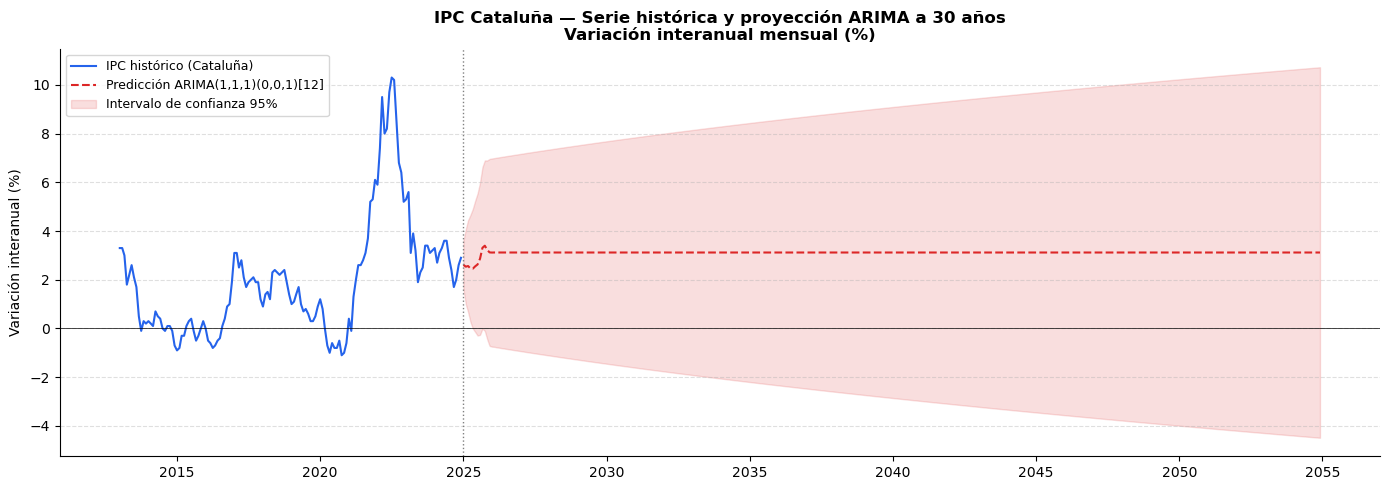

In [79]:
fig, ax = plt.subplots(figsize=(14, 5))

# Serie histórica
fechas_historicas = pd.date_range(start="2013-01", periods=144, freq="MS")
ax.plot(fechas_historicas, serie_ipc, color="#2563EB", linewidth=1.5, label="IPC histórico (Cataluña)")

# Predicción
ax.plot(df_forecast["fecha"], df_forecast["ipc_pred"], color="#DC2626", linewidth=1.5, linestyle="--", label="Predicción ARIMA(1,1,1)(0,0,1)[12]")

# Intervalo de confianza al 95%
ax.fill_between(
    df_forecast["fecha"],
    df_forecast["ipc_lower"],
    df_forecast["ipc_upper"],
    alpha=0.15,
    color="#DC2626",
    label="Intervalo de confianza 95%"
)

# Línea vertical separando histórico de predicción
ax.axvline(pd.Timestamp("2025-01"), color="gray", linestyle=":", linewidth=1)
ax.axhline(0, color="black", linewidth=0.5, linestyle="-")

ax.set_title(
    "IPC Cataluña — Serie histórica y proyección ARIMA a 30 años\nVariación interanual mensual (%)",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("Variación interanual (%)", fontsize=10)
ax.set_xlabel("")
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("bloque3_arima_ipc_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

CAGR provincial

In [104]:
# Media anual de la predicción ARIMA por año
ipc_anual_pred = (
    df_forecast
    .groupby("año")["ipc_pred"]
    .mean()
    .round(4)
    .reset_index()
    .rename(columns={"ipc_pred": "ipc_arima_pct"})
)

# Tasa de largo plazo ARIMA (media de los 30 años proyectados)
ipc_arima_largoplazo = round(ipc_anual_pred["ipc_arima_pct"].mean(), 4)

print("IPC proyectado anual (ARIMA):")
print(ipc_anual_pred.to_string(index=False))
print(f"\nTasa de largo plazo ARIMA: {ipc_arima_largoplazo}%")

IPC proyectado anual (ARIMA):
 año  ipc_arima_pct
2025         2.8105
2026         3.1177
2027         3.1178
2028         3.1178
2029         3.1178
2030         3.1178
2031         3.1178
2032         3.1178
2033         3.1178
2034         3.1178
2035         3.1178
2036         3.1178
2037         3.1178
2038         3.1178
2039         3.1178
2040         3.1178
2041         3.1178
2042         3.1178
2043         3.1178
2044         3.1178
2045         3.1178
2046         3.1178
2047         3.1178
2048         3.1178
2049         3.1178
2050         3.1178
2051         3.1178
2052         3.1178
2053         3.1178
2054         3.1178

Tasa de largo plazo ARIMA: 3.1076%


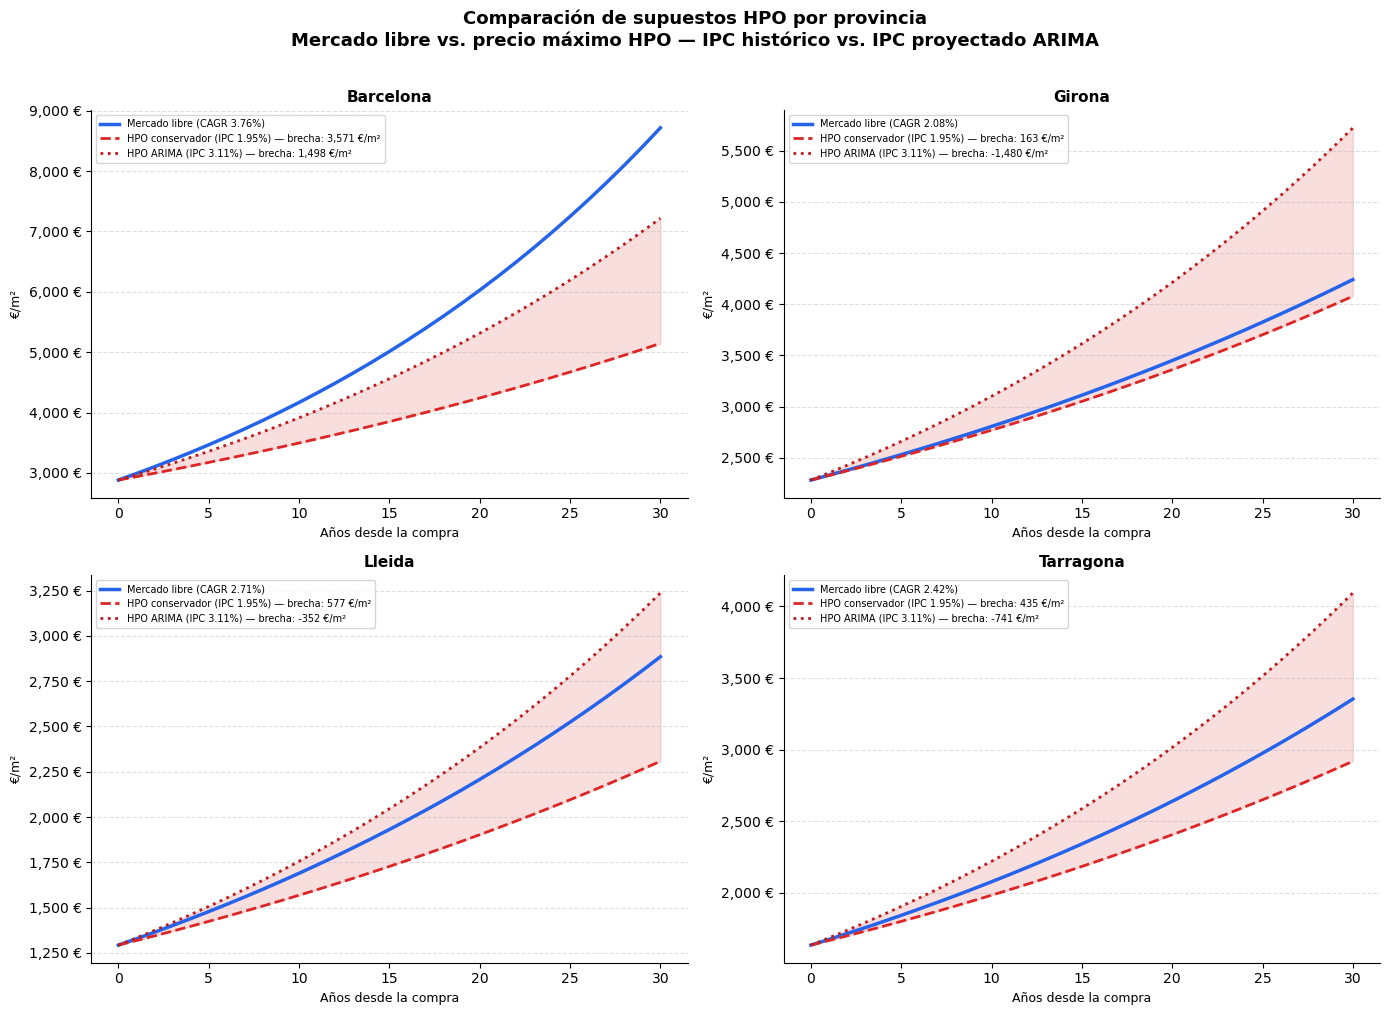

In [108]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, provincia in enumerate(provincias):
    ax = axes[i]

    precio_base = df_cagr_provincias[
        df_cagr_provincias["provincia"] == provincia
    ]["precio_2024"].values[0]

    cagr_val = df_cagr_provincias[
        df_cagr_provincias["provincia"] == provincia
    ]["cagr"].values[0]

    # Proyecciones
    df_mercado = proyectar_curvas(precio_base, cagr_val, ipc_medio_historico, n_años=años_proyeccion)
    df_hpo_hist = proyectar_curvas(precio_base, ipc_medio_historico, ipc_medio_historico, n_años=años_proyeccion)
    df_hpo_arima = proyectar_curvas(precio_base, ipc_arima_largoplazo, ipc_arima_largoplazo, n_años=años_proyeccion)

    # Brechas al año 30
    brecha_hist = round(
        df_mercado[df_mercado["año_proyeccion"] == 30]["precio_mercado_m2"].values[0] -
        df_hpo_hist[df_hpo_hist["año_proyeccion"] == 30]["precio_hpo_m2"].values[0], 0
    )
    brecha_arima = round(
        df_mercado[df_mercado["año_proyeccion"] == 30]["precio_mercado_m2"].values[0] -
        df_hpo_arima[df_hpo_arima["año_proyeccion"] == 30]["precio_hpo_m2"].values[0], 0
    )

    # Banda entre las dos curvas HPO
    ax.fill_between(
        df_mercado["año_proyeccion"],
        df_hpo_hist["precio_hpo_m2"],
        df_hpo_arima["precio_hpo_m2"],
        alpha=0.15, color="#DC2626", label="_nolegend_"
    )

    # Curva mercado
    ax.plot(df_mercado["año_proyeccion"], df_mercado["precio_mercado_m2"],
            color="#2563EB", linewidth=2.5,
            label=f"Mercado libre (CAGR {cagr_val:.2f}%)")

    # Curva HPO histórico
    ax.plot(df_hpo_hist["año_proyeccion"], df_hpo_hist["precio_hpo_m2"],
            color="#DC2626", linewidth=2, linestyle="--",
            label=f"HPO conservador (IPC {ipc_medio_historico:.2f}%) — brecha: {brecha_hist:,.0f} €/m²")

    # Curva HPO ARIMA
    ax.plot(df_hpo_arima["año_proyeccion"], df_hpo_arima["precio_hpo_m2"],
            color="#B91C1C", linewidth=2, linestyle=":",
            label=f"HPO ARIMA (IPC {ipc_arima_largoplazo:.2f}%) — brecha: {brecha_arima:,.0f} €/m²")

    ax.set_title(f"{provincia}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Años desde la compra", fontsize=9)
    ax.set_ylabel("€/m²", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €"))
    ax.legend(fontsize=7)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Comparación de supuestos HPO por provincia\n"
    "Mercado libre vs. precio máximo HPO — IPC histórico vs. IPC proyectado ARIMA",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("bloque3_viz_arima_vs_historico_provincias.png", dpi=150, bbox_inches="tight")
plt.show()